# Released J-lens vs R-lens readouts — qwen3.5-4b

Side-by-side readouts of the **released** J-lens and R-lens on the post's qualitative prompts.

> **Expected null:** the post reports *no* R-vs-J advantage on the smallest dense model (4b).
> Small/no differences below are the expected result; the R>J effect lives on 9b/27b.
> This notebook exists to validate the readout tooling and give a qualitative baseline.

In [1]:
import os, sys
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

import torch, transformers, pandas as pd
import jlens
from jlens.lens import JacobianLens
from rlens.analysis import read_prompt, topk_table, rank_trajectory

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16
print(f"device={DEVICE}")

device=cpu


In [2]:
hf = transformers.AutoModelForCausalLM.from_pretrained("Qwen/Qwen3.5-4B", dtype=DTYPE, device_map=DEVICE)
tok = transformers.AutoTokenizer.from_pretrained("Qwen/Qwen3.5-4B")
model = jlens.from_hf(hf, tok)

lenses = {
    "J": JacobianLens.load(str(REPO / "lenses/released/qwen3.5-4b/j-lens/lens.pt")),
    "R": JacobianLens.load(str(REPO / "lenses/released/qwen3.5-4b/r-lens/lens.pt")),
}
# Add our fitted lenses as extra columns once M4's fits exist:
for name, p in {"ours-J": "lenses/ours/qwen3.5-4b/j-lens/lens.pt", "ours-R": "lenses/ours/qwen3.5-4b/r-lens/lens.pt"}.items():
    if (REPO / p).exists():
        lenses[name] = JacobianLens.load(str(REPO / p))
print({k: repr(v) for k, v in lenses.items()})

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/426 [00:00<?, ?it/s]

{'J': 'JacobianLens(d_model=2560, n_prompts=25, source_layers=[0..30] (31 layers))', 'R': 'JacobianLens(d_model=2560, n_prompts=25, source_layers=[0..30] (31 layers))'}


In [3]:
def find_position(prompt: str, needle: str) -> int:
    """Absolute index of the last prompt token whose decoded text contains needle."""
    ids = model.encode(prompt)[0].tolist()
    hits = [i for i, t in enumerate(ids) if needle in tok.decode([t])]
    if not hits:
        raise ValueError(f"{needle!r} not found in {[tok.decode([t]) for t in ids]}")
    return hits[-1]

def side_by_side(prompt: str, *, pin: str, at: str, k: int = 3):
    """Top-k layer x position tables for every lens + pinned-token rank trajectories."""
    pos = find_position(prompt, at)
    tables, ranks = {}, {}
    for name, lens in lenses.items():
        r = read_prompt(lens, model, prompt)
        tables[name] = topk_table(r, tok, k=k)
        ranks[name] = rank_trajectory(r, tok, pin, position=pos)["rank"]
    print(f"prompt: {prompt!r}\npinned {pin!r} at position {pos} ({at!r} token)")
    return tables, pd.DataFrame(ranks)

## 1. Two-hop: sushi → Japan (pin " Japan" on the sushi token)

In [4]:
tables_sushi, ranks_sushi = side_by_side(
    "The capital of the country where sushi originated is", pin="Japan", at="sushi")
ranks_sushi

prompt: 'The capital of the country where sushi originated is'
pinned 'Japan' at position 6 ('sushi' token)


,J,R
layer,,
0,73938,28778
1,96316,25971
2,115329,45373
3,43856,7754
4,44185,13039
5,24852,4846
6,235,14
7,1423,93
8,102,14


In [5]:
tables_sushi["J"]

,0:'The',1:' capital',2:' of',3:' the',4:' country',5:' where',6:' sushi',7:' originated',8:' is'
L0,jenigen iếu orest,-capital izations ised,​​ اظ dong,s orest roller,hurt eur сь,ings houses десят,ٰ sushi ψη,ized okrat öst,otope cola pector
L1,–and …but “…,ization -capital izations,​​,“… s ‘’,hurt enje 裡,quiera ings houses,� واره ٰ,ized osis istics,otope pector cola
L2,amay endam FINE,capitals Capitals -capital,​​ � ❤,oare oise ´s,splitted nowadays equipments,quiera houses ings,sushi elai quist,osis ness ized,্ত encontre laut
L3,‥ jenigen umeur,capitals Capitals capital,​​ destiny a,忱 Roos mainly,nowadays equipments splitted,ings quiera houses,sushi � 🙂,osis solely 华裔,otope ning ্ত
L4,jenigen oarece necessities,capital capitals ised,​​ destiny a,fold 忱 在内,nowadays 裡 organisation,ings quiera houses,sushi � واره,solely osis Whilst,otope ning lab
L5,jenigen specialised 部份,ised isation capitals,​​ ing a,latter mainly fold,nowadays mainly equipments,quiera houses ings,sushi � �,ship solely stemming,otope can phen
L6,!) andai –and,capital capitals ised,​​ destiny a,latter 在内 fold,(country nowadays countries,houses quiera upon,sushi 寿司 �,ship ness stemming,마자 -capital capital
L7,tring laboratories Moreover,capitals capital Capitals,​​ a ator,fold Motto immense,countries (country country,houses quiera upon,sushi 寿司 Sushi,ship 华裔 originated,capital capital 마자
L8,"laboratories Shall ®,",capital capitals -capital,​​ lakes a,fold village territories,country (country countries,houses quiera upon,sushi 寿司 Sushi,华裔 ship originated,-capital capital cities
L9,laboratories laboratory ;-,capital capitals -capital,​​ cities lakes,village territories fold,country countries (country,houses quiera ____,sushi 寿司 Sushi,华裔 historically originated,cities capital city


In [6]:
tables_sushi["R"]

,0:'The',1:' capital',2:' of',3:' the',4:' country',5:' where',6:' sushi',7:' originated',8:' is'
L0,somew …it –and,-capital capital CAPITAL,somew …it –and,somew whats …it,–and [… exac,somew atleast whats,sushi fication вершенство,solely intit entimes,somew encontre …it
L1,…it –and […,-capital handl avig,somew ‘’ ….,somew [… …it,–and 人关注 […,quiera occas somew,–and sushi 站内搜索,solely entimes intit,somew encontre diety
L2,[… somew …it,capital -capital capitals,[… somew anyways,somew [… anyways,nowadays splitted organisation,abouts quiera everybody,sushi _( –and,solely amongst whilst,somew encontre –and
L3,somew amator にあた,capital capitals Capital,somew wich […,somew thems scrut,nowadays organisation mainly,quiera abouts ..........,sushi Sushi 寿司,somew solely 辿,somew encontre whats
L4,somew amator にあた,capital capitals Capital,wich somew tyt,somew 呼声 scrut,organisation nowadays mainly,quiera abouts youngsters,sushi Sushi 寿司,solely 辿 somew,somew encontre whats
L5,somew amator organisation,capital capitals Capital,wich somew thanks,somew wich 呼声,nowadays mainly supposed,quiera everybody abouts,sushi Sushi 湾区,Originally originating somew,somew alot whats
L6,tantal somew strugg,capital capitals Capital,capital somew its,somew spring pool,country organisation people,quiera upon people,sushi japon Sushi,Originally originally somew,capital somew capital
L7,thems somew tantal,capital capitals Capital,its population capital,somew spring pool,country continent countries,quiera upon people,sushi japon Sushi,Originally originally originating,capital capital Capital
L8,somew thems にあた,capital capitals Capital,capital population residence,region most population,country nation continent,quiera upon people,sushi japon Japon,Originally 华裔 originally,capital capital Capital
L9,somew thanks thems,capital capitals Capital,capital residence premier,village elected region,country country nation,quiera ____ ____,sushi japon Japon,Originally historically origins,capital capital столиц


## 2. Typo: "aganst" (pin " against")

In [7]:
tables_typo, ranks_typo = side_by_side(
    "The senator explained that she voted aganst the bill on principle.", pin="against", at="anst")
ranks_typo

prompt: 'The senator explained that she voted aganst the bill on principle.'
pinned 'against' at position 7 ('anst' token)


,J,R
layer,,
0,57904,149617
1,17021,88556
2,1060,467
3,263,83
4,675,76
5,266,66
6,58,29
7,53,28
8,44,28


In [8]:
tables_typo["J"]

,0:'The',1:' senator',2:' explained',3:' that',4:' she',5:' voted',6:' ag',7:'anst',8:' the',9:' bill',10:' on',11:' principle',12:'.'
L0,jenigen iếu orest,ization ized zelfde,o ément ly,o zelfde ively,ez e ea,s ted ing,s enerative sos,ة ness itude,s er a,ings mong zinho,rnd ned /off,ed — –,"psc .""). ﻿"
L1,–and …but “…,ization ized zelfde,o ed ément,o zelfde a,ez ea ei,ted s tin,s i sos,ة ness 但不限于,s a e,mong zinho ings,thern behalf ned,ed i –,–and …but …it
L2,amay endam FINE,ization senator ize,一点儿 ément splitted,o zelfde ele,ea ez herself,ted tio tin,s 然是 gers,ة ness Colour,s sia tb,ings iard mong,ned behalf /off,bene bdd ––,**.** everybody мести
L3,‥ jenigen umeur,ization ized ize,ément rab ré,o zelfde e,e ea ez,ted tin aled,s i gers,ة ness Colour,s e tb,iard ings iards,ned behalf /off,bene arity arily,ationale --------- ….
L4,jenigen oarece necessities,ization ize senator,o ة why,o e ez,ea herself ez,tin aled ted,s gers sos,ة ness 但不限于,s er latter,ings iard iards,ned behalf /off,moreover arity nevertheless,oose \n\n that
L5,jenigen specialised 部份,ize senator ization,o ​​ why,o ​​ zelfde,herself e ́,voted turnout ing,s en i,ة ness ive,"s : ,",ings iard till,behalf ned /off,nevertheless rather nonetheless,\n\n \n\n ??
L6,!) andai –and,senator ize ization,edly ed why,o ez zelfde,herself she hers,ing against voted,s i en,ة ness ive,"s , opposition",ings iard shaw,behalf ned /off,matters rather istic,", why"
L7,tring laboratories Moreover,senator ize ization,why edly ed,o a economic,herself she she,voted vote voting,s i en,ة ness ive,"s ee ,",iard unconstitutional ings,behalf ned /off,matters istic of,\n\n . \n\n
L8,"laboratories Shall ®,",senator ize legisl,why ed edly,o economic a,herself she hers,voted vote voting,s en i,ة ness ive,s ee political,unconstitutional legislation 法案,behalf ned /off,matters istic rather,why \n \n\n
L9,laboratories laboratory ;-,senator legisl senators,why explained edly,o economic federal,herself she her,voting vote voted,s en i,ة ness bele,vote amendments amendment,unconstitutional legislation 法案,behalf voted voting,matters prag wrest,\n\n \n


In [9]:
tables_typo["R"]

,0:'The',1:' senator',2:' explained',3:' that',4:' she',5:' voted',6:' ag',7:'anst',8:' the',9:' bill',10:' on',11:' principle',12:'.'
L0,somew …it –and,–and —and senator,somew [… –and,somew 😀 scrut,somew 🙂 😉,–and somew にあた,agment somew 原件及,whilst atleast rumours,somew whats seperate,encontre handl **•,"somew ,on whats",whilst harbour Whilst,somew …it –and
L1,…it –and […,–and wes senator,[… somew (…),somew [… …it,somew –and **.**,somew alot toc,agment 原件及 glom,seperate atleast recieved,somew seperate ‘’,тім obiec –and,"somew ­ ,on",whilst diety şti,–and somew …it
L2,[… somew …it,senator legisl wes,[… (…) afterwards,[… somew afterward,–and hers herself,票数 voted […,s ging rag,whilst seperate organised,somew whats thems,mong тім wagon,"...... .......... ,on",ostensibly diety whilst,…. somew whats
L3,somew amator にあた,senator wes –and,[… (…) somew,somew [… (…),somew –and hers,vote somew voted,ong ay s,rumours favour organised,somew thems whats,iard 原件及 тім,whats somew ned,diety ostensibly spok,whats somew scrut
L4,somew amator にあた,senator legisl fish,[… somew 気に入りの,[… (…) ..........,somew herself hers,ballots voted somew,meds ong ってる,rumours criticised harbour,thems somew whats,BILL upstairs straight,"somew whats ,on",notwithstanding ostensibly rather,whats somew かなか
L5,somew amator organisation,senator legisl fish,[… why 気に入りの,[… somew (…),herself hers somew,voted vote ballots,meds ってる s,isnt seperate didnt,thems diety pool,atleast sometime BILL,whats Mondays wers,ostensibly rather largely,whats isnt didnt
L6,tantal somew strugg,senator legisl Legis,why afterward […,somew immediately initially,herself she hers,voted vote voting,s ong t,didnt isnt against,vote pool voted,tonight iard Legis,didnt wers behalf,rather l of,didnt why whats
L7,thems somew tantal,senator legisl elected,why how afterward,____ immediately afterward,herself she hers,vote voted voting,s ong t,against didnt alot,すすめ vote pool,vote fish board,wers voted behalf,rather grounds of,didnt straight why
L8,somew thems にあた,senator legisl elected,why how afterward,____ immediately traged,herself she hers,vote voted voting,s t i,didnt bele dont,vote voted voting,vote legislation bill,wers voted behalf,rather grounds rallied,why 为什么不 why
L9,somew thanks thems,senator legisl elected,why how explain,federal ____ immediately,herself she hers,vote voting voted,s t i,"alot bele ,",vote voted voting,vote 草案 legislation,voting voted vote,grounds rallied rather,.......... .... why


## 3. Association: Michael Jordan → basketball (pin " basketball" on the Jordan token)

In [10]:
tables_mj, ranks_mj = side_by_side(
    "The athlete Michael Jordan plays the sport of", pin="basketball", at="Jordan")
ranks_mj

prompt: 'The athlete Michael Jordan plays the sport of'
pinned 'basketball' at position 3 ('Jordan' token)


,J,R
layer,,
0,12656,31743
1,12105,17236
2,4740,3269
3,3376,496
4,2033,224
5,864,41
6,58,3
7,19,3
8,3,0


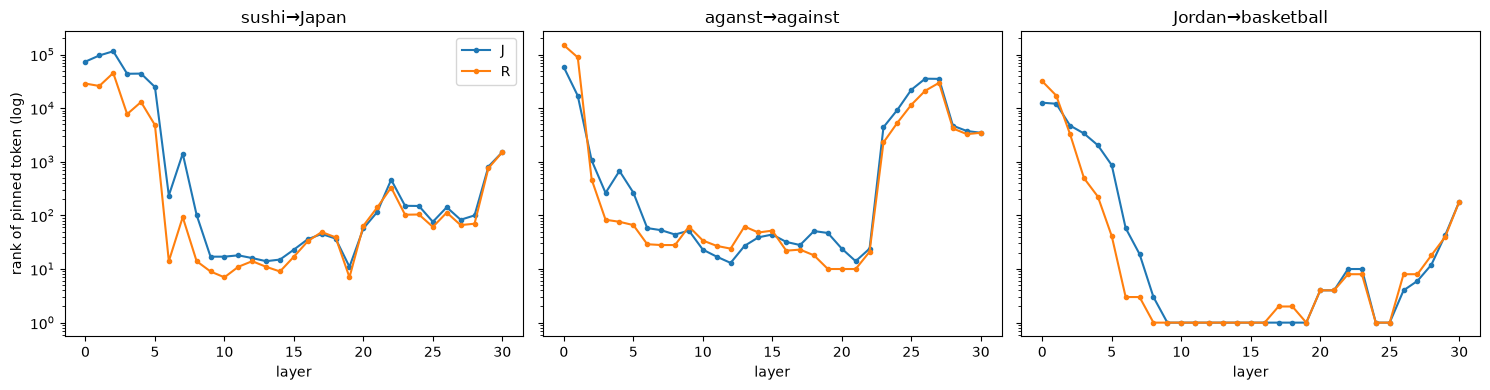

In [11]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (title, ranks) in zip(axes, [("sushi→Japan", ranks_sushi), ("aganst→against", ranks_typo), ("Jordan→basketball", ranks_mj)]):
    layer_rows = ranks.drop(index="final")
    for name in layer_rows.columns:
        ax.plot(layer_rows.index.astype(int), layer_rows[name].clip(lower=1), marker="o", ms=3, label=name)
    ax.set_yscale("log"); ax.set_title(title); ax.set_xlabel("layer")
axes[0].set_ylabel("rank of pinned token (log)"); axes[0].legend()
plt.tight_layout(); plt.show()

## Observations

- Both lenses surface the pinned concepts at mid layers, far earlier than the logit lens (see `scripts/smoke_test.py` for the logit-lens baseline).
- **The J/R difference on 4b is small — this is the expected null.** The post reports no R advantage
  on the smallest dense model; the early-layer R>J effect is expected to appear on qwen3.5-9b/27b.
  A small or even sign-flipped gap here is *not* evidence against the replication.
- Once `lenses/ours/` exists (M4 fits), re-running this notebook adds our fitted lenses as extra
  columns in the rank tables above (the loader cell picks them up automatically).